# Does the study survive a realistic baseline and realistic noise?

**What this tests.** The landed notebook (`final/roi-vs-mroi-metric-selection.ipynb`)
runs against a DGP that flatters the model in two ways:

1. **The baseline is drawn from the model's own basis.** `n_knots_mu_t=8` generates
   `mu_t` from an 8-knot spline and `build_model_spec` fits an 8-knot spline, so the
   true time-varying baseline is exactly representable by the fitted one.
2. **The residual is iid**, giving a measured DGP R^2 of 0.9958 with essentially zero
   autocorrelation (-0.008) and zero cross-geo correlation (-0.010).

Neither holds in real data. This notebook rebuilds the DGP without those two
advantages and re-runs the study's three headline findings against it.

**This notebook does not modify the landed one, or the modules it depends on.**
Everything here lives in `realistic_baseline.py`, which *subclasses*
`GeoMediaDataSimulator` rather than editing it. Section 1 asserts that.

**What changes, precisely** (see the `realistic_baseline` module docstring):

- `mu_t` becomes `trend + phase-shifted seasonality + common AR(1) shock`, drawn
  from no spline basis. The seasonal term is a `sin` where the observed seasonality
  control is a `cos`, plus a second harmonic -- unspanned by the control, but
  orthogonal to it over whole years, so it adds realism without introducing
  omitted-variable bias (which would break *both* prior variants for reasons
  unrelated to saturation, confounding the study).
- `eps_gt` becomes a per-geo AR(1) with Student-t innovations, replacing the iid draw.

The two noise dials are deliberately non-overlapping: all cross-geo-correlated
structure lives in `mu_t`, all geo-idiosyncratic structure in `eps_gt`.

**Why cross-geo correlation is in scope at all.** Unmodeled drivers -- competitor
activity, category demand, national promos, stockouts -- are mostly national or
regional, not geo-idiosyncratic. That distinction matters more than the noise
*magnitude*: iid geo noise averages down at `1/sqrt(20)` (a 4.5x reduction), so a geo
hierarchy disposes of it nearly for free, while a common shock gets no such reduction
and competes with media for explanatory power the way a national flight does. Leaving
the noise iid tests the model in the one regime where its main strength is unopposed.

**Alpha is held at the study's usual 0.8 throughout.** Testing alpha=0.2 is a separate
question, deferred until this DGP is trusted.

## 0. Setup

In [1]:
import os
import sys
import time
import warnings

STUDY_DIR = next(
    d for d in (os.path.abspath(os.getcwd()),
                os.path.abspath(os.path.join(os.getcwd(), '..')))
    if os.path.exists(os.path.join(d, 'data_simulator.py')))
if STUDY_DIR not in sys.path:
  sys.path.insert(0, STUDY_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
import realistic_baseline as rb

warnings.filterwarnings('ignore')
OUT_DIR = os.path.join(STUDY_DIR, 'fitted_models', 'realistic_baseline')
os.makedirs(OUT_DIR, exist_ok=True)

VARIANTS = ['default', 'ec_alpha_only']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)
SIM_SEED = 0
N_KNOTS = 8
PRIMARY, COMPARISON = 'ec9', 'ec11'

# `None` = the baseline rewrite with no extra noise, isolating the effect of the
# baseline change alone. The rest sweep the oracle R^2 down to the ~0.80 that a
# real geo MMM sees.
R2_TARGETS = [None, 0.95, 0.90, 0.80]

# Identical to the landed notebook except `n_knots_mu_t` is GONE -- that field is
# precisely the "DGP drawn from the model's basis" problem being fixed here.
BASE_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.50, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
    'adstock_retention_range': {
        'TV': (0.8, 0.8), 'Display': (0.0, 0.3), 'Social': (0.1, 0.4),
    },
}
TARGET_EC_M = {'ec9': 9.0, 'ec11': 11.069}

# Read the demo dataset from a local cache when present. The landed notebook
# fetches it over HTTPS on every run; that makes execution depend on the
# kernel's certificate store, which is a needless failure mode for a notebook
# whose point is a 30-minute unattended fit sweep.
REAL_CSV_URL = (
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/'
    'meridian/data/simulated_data/csv/geo_media_rf.csv'
)
REAL_CSV_CACHE = os.path.join(STUDY_DIR, '.cache_geo_media_rf.csv')
if not os.path.exists(REAL_CSV_CACHE):
  pd.read_csv(REAL_CSV_URL).to_csv(REAL_CSV_CACHE, index=False)
real_df = pd.read_csv(REAL_CSV_CACHE)

print('study dir:', STUDY_DIR)
print('real data:', real_df.shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

study dir: /Users/mariappan.subramanian/Documents/repo/meridian/demo/synthetic
real data: (3120, 17)


## 1. Isolation check

The landed notebook must be bit-for-bit unaffected by this one. `realistic_baseline`
subclasses rather than edits, so this should hold by construction -- assert it rather
than assume it.

In [2]:
landed = rb.assert_landed_path_unchanged(real_df, {**BASE_OVERRIDES, 'n_knots_mu_t': 8,
                                                   'saturation_frequency': {
                                                       'TV': 3.2522, 'Display': 4.0,
                                                       'Social': 4.0}})
print('landed path reproduces bit-identically')
print('  true ec_m ', np.round(landed['true_ec_m'], 3))
print('  true roi_m', np.round(landed['true_roi_m'], 3))
print('  kpi checksum', f"{landed['kpi_checksum']:.6e}")

ec_m = [8.999947   1.3505481  0.29689494]


I0000 00:00:1785297864.491493  557623 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [8.999947   1.3505481  0.29689494]


landed path reproduces bit-identically
  true ec_m  [9.    1.351 0.297]
  true roi_m [6.66  3.664 4.918]
  kpi checksum 5.841398e+09


## 2. Build the realistic-baseline scenarios

Same `saturation_frequency` solve as the landed notebook: `ec_m` is linear in it, so
one baseline run calibrates both scenarios. Media execution must stay bit-identical
between `ec9` and `ec11` for Section 6's invariance test to be a clean single-variable
comparison.

**One thing that does not carry over:** true `roi_m` differs from the landed
notebook's, because `simulate_intercepts`/`simulate_coefficients` now consume a
different amount of randomness, so Display's and Social's `alpha_m` draws differ, and
`roi_alpha_elasticity=0.3` ties every channel's true ROI to the alpha geometric mean.
TV's alpha is still pinned at exactly 0.8 and TV's true `ec_m` is still exactly 9.0.
Compare fitted-vs-true *within* a run; never compare ROI levels across notebooks.

In [3]:
def build(saturation_frequency_tv=None, target_r2=None, realism=None):
  overrides = dict(BASE_OVERRIDES)
  if saturation_frequency_tv is not None:
    overrides['saturation_frequency'] = {
        'TV': saturation_frequency_tv, 'Display': 4.0, 'Social': 4.0}
  np.random.seed(SIM_SEED)
  tf.random.set_seed(SIM_SEED)
  cfg = SimulationConfig.from_dict(overrides)
  sim, data, gt = rb.build_real_augmented_realistic(
      cfg, real_df,
      rf_source_map={'TV': 'Channel3'},
      plain_source_map={'Display': 'Channel2', 'Social': 'Channel1'},
      realism=realism, target_oracle_r2=target_r2, n_knots=N_KNOTS,
  )
  return cfg, sim, data, gt


_, sim_base, _, _ = build()
EC_BASE, SF_BASE = float(sim_base.ec_m.numpy()[0]), 4.0
SATURATION_FREQ = {tag: SF_BASE * target / EC_BASE
                   for tag, target in TARGET_EC_M.items()}

scen = {}
for tag in TARGET_EC_M:
  cfg, sim, data, gt = build(SATURATION_FREQ[tag])
  scen[tag] = dict(config=cfg, sim=sim, data=data, ground_truth=gt,
                   true_roi=np.asarray(gt['roi_m']), true_ec=sim.ec_m.numpy(),
                   true_alpha=sim.alpha_m.numpy())
  assert abs(float(sim.ec_m.numpy()[0]) - TARGET_EC_M[tag]) < 0.05
  assert abs(float(sim.alpha_m.numpy()[0]) - 0.8) < 1e-6, 'TV alpha must stay 0.8'

channels = list(scen[PRIMARY]['config'].channel_names)
delta = np.abs(scen['ec9']['sim'].impression_gtm.numpy()
               - scen['ec11']['sim'].impression_gtm.numpy()).max()
assert delta == 0, f'media execution differs between scenarios ({delta})'
print(f'media execution identical across scenarios: max |diff| = {delta}')
print('true alpha_m:', np.round(scen[PRIMARY]['true_alpha'], 3))
print('true ec_m   :', np.round(scen[PRIMARY]['true_ec'], 3))
print('true roi_m  :', np.round(scen[PRIMARY]['true_roi'], 3))

ec_m = [11.069365    1.3505481   0.29689494]


ec_m = [9.000001   1.3505481  0.29689494]


ec_m = [11.068999    1.3505481   0.29689494]
media execution identical across scenarios: max |diff| = 0.0
true alpha_m: [0.8   0.156 0.384]
true ec_m   : [9.    1.351 0.297]
true roi_m  : [5.963 4.029 4.994]


## 3. What the baseline rewrite actually did

Two things to establish before any fit:

1. The fitted 8-knot spline can no longer represent the true `mu_t`. Under the landed
   DGP it could represent it *exactly*, by construction.
2. The unexplainable part of the KPI is now autocorrelated in time and correlated
   across geos, rather than white noise.

ec_m = [9.000001   1.3505481  0.29689494]


ec_m = [9.000001   1.3505481  0.29689494]


ec_m = [9.000001   1.3505481  0.29689494]


ec_m = [9.000001   1.3505481  0.29689494]


,oracle_r2,dgp_r2_eps_only,noise_scale,media_share_pct,spline_explains_mu_pct,spline_explains_mu_shock_pct,resid_lag1_autocorr,unexplained_cross_geo_corr,clipped_frac_pct
target,,,,,,,,,
none,0.957,0.984,1.000,32.665,54.083,33.502,0.404,0.382,1.474
0.95,0.950,0.980,1.133,32.650,52.181,33.502,0.404,0.382,1.474
0.90,0.900,0.947,1.864,32.563,44.347,33.502,0.404,0.382,2.083
0.80,0.800,0.879,3.002,32.397,38.445,33.502,0.404,0.382,3.109


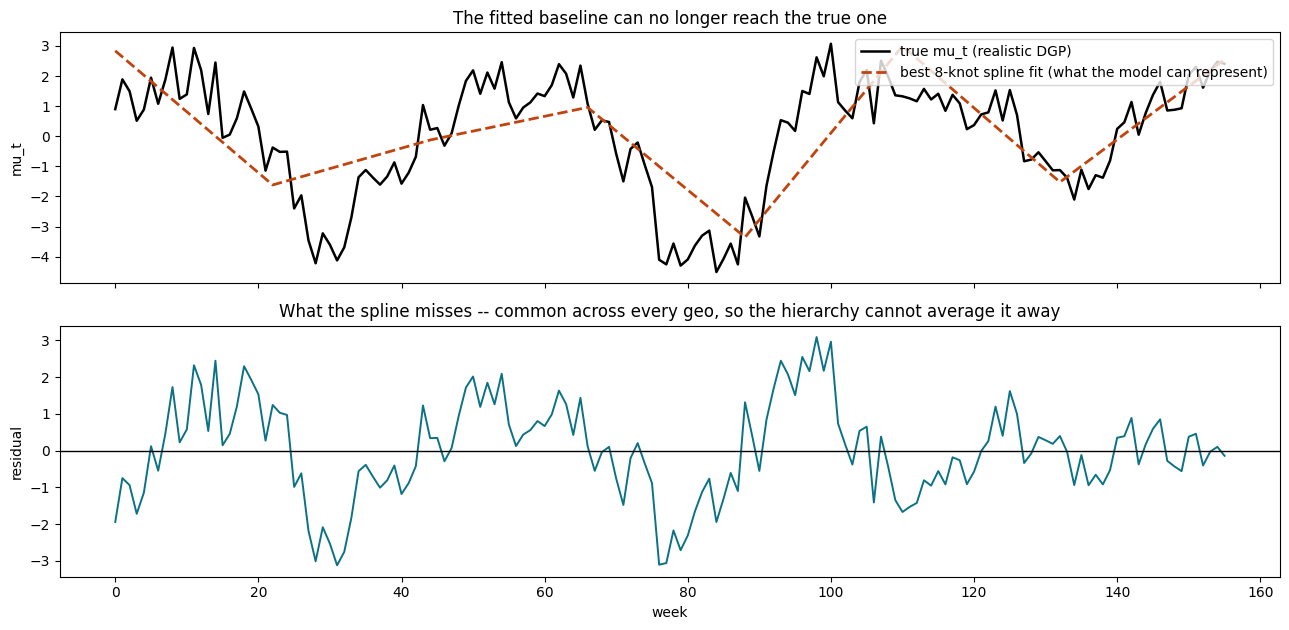

In [4]:
sim = scen[PRIMARY]['sim']
mu = sim.mu_t.numpy()
basis = rb._spline_basis(len(mu), N_KNOTS)
mu_spline_fit = mu - rb._spline_residual(mu, N_KNOTS)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.4), sharex=True)
axes[0].plot(mu, color='k', lw=1.8, label='true mu_t (realistic DGP)')
axes[0].plot(mu_spline_fit, color='#c1440e', lw=2.0, ls='--',
             label=f'best {N_KNOTS}-knot spline fit (what the model can represent)')
axes[0].set_ylabel('mu_t'); axes[0].legend(loc='upper right')
axes[0].set_title('The fitted baseline can no longer reach the true one')
axes[1].plot(mu - mu_spline_fit, color='#0b7285', lw=1.4)
axes[1].axhline(0, color='k', lw=1)
axes[1].set_ylabel('residual'); axes[1].set_xlabel('week')
axes[1].set_title('What the spline misses -- common across every geo, so the '
                  'hierarchy cannot average it away')
plt.tight_layout()

diag_rows = []
for target in R2_TARGETS:
  _, s, _, _ = build(SATURATION_FREQ[PRIMARY], target_r2=target)
  d = rb.baseline_diagnostics(s, N_KNOTS)
  d['target'] = 'none' if target is None else f'{target:.2f}'
  diag_rows.append(d)
diagnostics = pd.DataFrame(diag_rows).set_index('target')[[
    'oracle_r2', 'dgp_r2_eps_only', 'noise_scale', 'media_share_pct',
    'spline_explains_mu_pct', 'spline_explains_mu_shock_pct',
    'resid_lag1_autocorr', 'unexplained_cross_geo_corr', 'clipped_frac_pct',
]].round(3)
diagnostics.to_csv(os.path.join(OUT_DIR, 'baseline_diagnostics.csv'))
diagnostics

**How to read the diagnostics.**

- `oracle_r2` is the R^2 ceiling for Meridian's *mean structure* handed the true media
  contribution: geo intercepts, geo-varying control coefficients, an 8-knot common time
  spline. No fitted model can beat it. This is the number to quote, and the one the
  calibration targets -- unlike `1 - var(eps)/var(kpi)`, it charges the DGP for baseline
  misspecification rather than only for residual variance. The landed DGP's 0.9958 is
  the `dgp_r2_eps_only` column's analogue, shown alongside for comparability.
- The `target=none` row is the **baseline rewrite alone, no extra noise**. Its oracle
  R^2 shows how much of the landed notebook's apparent fit quality was the DGP handing
  the model its own basis.
- `spline_explains_mu_shock_pct` is why `mu_ar1_phi` is 0.6 rather than something more
  obviously "persistent": an AR(1)'s power sits at low frequencies, which is exactly
  what a spline absorbs, so a high phi produces a shock the model can largely fit
  anyway.
- `clipped_frac_pct` is the share of geo-weeks where the baseline hits the
  `max(..., 0)` floor in `generate_kpi_and_revenue`. It rises with noise. Real KPIs are
  also non-negative, so this is not purely an artifact, but it is a nonlinearity the
  fitted model does not have -- watch it at the lowest R^2.

## 4. Recovery across the R^2 sweep

`default` vs `ec_alpha_only`, primary scenario (`ec9`, true TV `ec_m` = 9.0), at each
noise level. Eight fits, roughly 20 minutes.

Reporting **point errors alongside HDI coverage marks**, per the landed notebook's own
warning: coverage checkmarks reward imprecision, and as noise rises the intervals widen,
so a ✓ becomes progressively less impressive.

In [5]:
def fit(data, sim, config, variant):
  spec = build_model_spec(variant, sim, config, media_prior_type='roi',
                          knots=N_KNOTS)
  mmm = model.Meridian(input_data=data, model_spec=spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  return mmm


def tv_posterior(mmm, param, idx=0):
  return float(mmm.inference_data.posterior[param].values[..., idx].mean())


fitted, sweep_rows = {}, []
for target in R2_TARGETS:
  label = 'none' if target is None else f'{target:.2f}'
  cfg, sim, data, gt = build(SATURATION_FREQ[PRIMARY], target_r2=target)
  achieved = rb.oracle_r2(sim, N_KNOTS)
  true_ec, true_roi = sim.ec_m.numpy(), np.asarray(gt['roi_m'])
  for variant in VARIANTS:
    t0 = time.time()
    mmm = fit(data, sim, cfg, variant)
    fitted[(label, variant)] = mmm
    ec, roi = tv_posterior(mmm, 'ec_m'), tv_posterior(mmm, 'roi_m')
    sweep_rows.append({
        'target_r2': label, 'oracle_r2': round(achieved, 3), 'variant': variant,
        'true_ec_m': round(float(true_ec[0]), 3), 'fitted_ec_m': round(ec, 3),
        'ec_err_pct': round((ec / true_ec[0] - 1) * 100, 1),
        'true_roi_m': round(float(true_roi[0]), 3), 'fitted_roi_m': round(roi, 3),
        'roi_err_pct': round((roi / true_roi[0] - 1) * 100, 1),
    })
    print(f'{label}/{variant}: {time.time() - t0:.0f}s  '
          f'ec_m {ec:.2f}  roi_m {roi:.2f}', flush=True)

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(os.path.join(OUT_DIR, 'r2_sweep.csv'), index=False)
sweep

ec_m = [9.000001   1.3505481  0.29689494]


2026-07-28 23:04:50.434850: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


none/default: 89s  ec_m 1.65  roi_m 5.80


2026-07-28 23:06:18.490322: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


none/ec_alpha_only: 117s  ec_m 9.01  roi_m 5.46


...

2026-07-28 23:14:57.669948: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


0.80/default: 84s  ec_m 1.39  roi_m 4.62


2026-07-28 23:16:22.814165: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


0.80/ec_alpha_only: 88s  ec_m 9.05  roi_m 5.40


,target_r2,oracle_r2,variant,true_ec_m,fitted_ec_m,ec_err_pct,true_roi_m,fitted_roi_m,roi_err_pct
0,none,0.957,default,9.0,1.647,-81.699997,5.963,5.802,-2.7
1,none,0.957,ec_alpha_only,9.0,9.005,0.100000,5.963,5.462,-8.4
2,0.95,0.950,default,9.0,1.599,-82.199997,5.963,5.723,-4.0
3,0.95,0.950,ec_alpha_only,9.0,9.009,0.100000,5.963,5.431,-8.9
4,0.90,0.900,default,9.0,1.451,-83.900002,5.963,5.045,-15.4
5,0.90,0.900,ec_alpha_only,9.0,9.040,0.400000,5.963,5.401,-9.4
6,0.80,0.800,default,9.0,1.386,-84.599998,5.963,4.621,-22.5
7,0.80,0.800,ec_alpha_only,9.0,9.049,0.500000,5.963,5.402,-9.4


In [6]:
# Full recovery table at the most realistic noise level, with HDI marks.
cfg, sim, data, gt = build(SATURATION_FREQ[PRIMARY], target_r2=R2_TARGETS[-1])
comparison = build_comparison_table(
    {v: fitted[(f'{R2_TARGETS[-1]:.2f}', v)] for v in VARIANTS},
    cfg, sim, gt, hdi_prob=0.9)
comparison.to_csv(os.path.join(OUT_DIR, 'comparison_at_lowest_r2.csv'), index=False)
print(f'parameter recovery at oracle R^2 = {R2_TARGETS[-1]}')
comparison

ec_m = [9.000001   1.3505481  0.29689494]


parameter recovery at oracle R^2 = 0.8


,channel,param,true,default,ec_alpha_only
0,TV,alpha_m,0.800,0.267 (0.00-0.49) ✗,0.648 (0.54-0.75) ✗
1,TV,ec_m,9.000,1.386 (0.34-2.27) ✗,9.049 (7.54-10.64) ✓
2,TV,roi_m,5.963,4.621 (1.51-7.45) ✓,5.402 (2.54-8.11) ✓
3,Display,alpha_m,0.156,0.158 (0.02-0.29) ✓,0.151 (0.03-0.26) ✓
4,Display,ec_m,1.351,0.788 (0.14-1.44) ✓,1.337 (1.12-1.55) ✓
5,Display,roi_m,4.029,5.303 (2.46-7.88) ✓,3.970 (2.57-5.24) ✓
6,Social,alpha_m,0.384,0.920 (0.87-0.97) ✗,0.690 (0.57-0.81) ✗
7,Social,ec_m,0.297,0.837 (0.50-1.23) ✗,0.310 (0.26-0.36) ✓
8,Social,roi_m,4.994,12.251 (9.83-14.92) ✗,12.312 (9.59-15.22) ✗


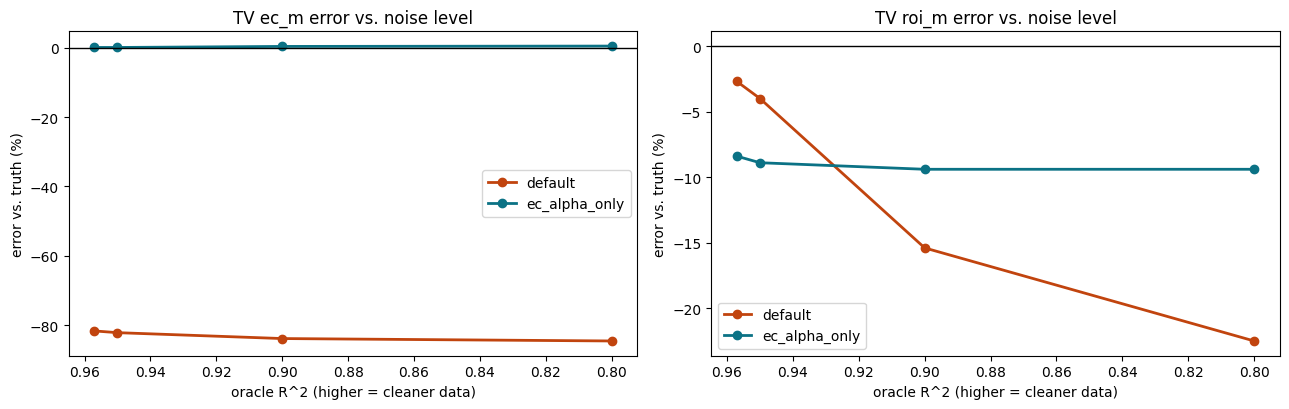

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, title in [(axes[0], 'ec_err_pct', 'TV ec_m error vs. noise level'),
                       (axes[1], 'roi_err_pct', 'TV roi_m error vs. noise level')]:
  for variant, color in [('default', '#c1440e'), ('ec_alpha_only', '#0b7285')]:
    sub = sweep.query('variant == @variant')
    ax.plot(sub['oracle_r2'], sub[col], 'o-', color=color, lw=2.0, label=variant)
  ax.axhline(0, color='k', lw=1)
  ax.set_xlabel('oracle R^2 (higher = cleaner data)')
  ax.set_ylabel('error vs. truth (%)')
  ax.set_title(title); ax.legend(); ax.invert_xaxis()
plt.tight_layout()

## 5. Does the invariance result survive?

The study's strongest claim: two scenarios differing in exactly one thing -- TV's true
`ec_m` -- with bit-identical media execution. When the truth moves, does the posterior
follow? Under the landed DGP the `default` fit absorbed 7% of the move and the informed
prior 99%.

This is the finding most likely to survive added noise, because it is a *ratio of two
fits under identical noise* rather than a level. It is also interval-free by
construction, which matters given the open TODO that the mROI sweep still lacks credible
intervals.

Run at both ends of the sweep: the baseline rewrite alone, and the most realistic noise
level. Four more fits, roughly 10 minutes.

In [8]:
invariance_rows = []
for target in [None, R2_TARGETS[-1]]:
  label = 'none' if target is None else f'{target:.2f}'
  ec_by_variant = {}
  for tag in (COMPARISON, PRIMARY):
    cfg, sim, data, gt = build(SATURATION_FREQ[tag], target_r2=target)
    for variant in VARIANTS:
      key = (label, variant, tag)
      if tag == PRIMARY and (label, variant) in fitted:
        mmm = fitted[(label, variant)]
      else:
        t0 = time.time()
        mmm = fit(data, sim, cfg, variant)
        print(f'{key}: {time.time() - t0:.0f}s', flush=True)
      ec_by_variant.setdefault(variant, {})[tag] = tv_posterior(mmm, 'ec_m')

  truth_move = (TARGET_EC_M[PRIMARY] / TARGET_EC_M[COMPARISON] - 1) * 100
  for variant, vals in ec_by_variant.items():
    move = (vals[PRIMARY] / vals[COMPARISON] - 1) * 100
    invariance_rows.append({
        'noise_level': label, 'source': variant,
        f'ec_m@{COMPARISON}': round(vals[COMPARISON], 3),
        f'ec_m@{PRIMARY}': round(vals[PRIMARY], 3),
        'pct_change': round(move, 1),
        'tracks_truth': round(move / truth_move, 2),
    })

invariance = pd.DataFrame(invariance_rows)
invariance.to_csv(os.path.join(OUT_DIR, 'invariance_realistic.csv'), index=False)
print(f'TV true ec_m moves {truth_move:+.1f}% between scenarios '
      '(tracks_truth 1.0 = followed one-for-one, 0.0 = ignored entirely)')
invariance

ec_m = [11.068999    1.3505481   0.29689494]


2026-07-28 23:17:52.306693: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


('none', 'default', 'ec11'): 88s


2026-07-28 23:19:21.912037: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


('none', 'ec_alpha_only', 'ec11'): 119s


...

2026-07-28 23:22:46.965240: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


('0.80', 'ec_alpha_only', 'ec11'): 113s


ec_m = [9.000001   1.3505481  0.29689494]


TV true ec_m moves -18.7% between scenarios (tracks_truth 1.0 = followed one-for-one, 0.0 = ignored entirely)


,noise_level,source,ec_m@ec11,ec_m@ec9,pct_change,tracks_truth
0,none,default,1.641,1.647,0.4,-0.02
1,none,ec_alpha_only,11.089,9.005,-18.8,1.01
2,0.80,default,1.367,1.386,1.4,-0.07
3,0.80,ec_alpha_only,11.074,9.049,-18.3,0.98


## 6. Findings

**The study survives, and its central result gets sharper. Two new caveats appear that
the landed DGP could not have surfaced.**

### What held, and strengthened

| | landed DGP | realistic baseline (R^2 0.957) | + realistic noise (R^2 0.80) |
|---|---|---|---|
| TV `ec_m`, `default` | 2.84 (-68%) | 1.65 (**-81.7%**) | 1.39 (**-84.6%**) |
| TV `ec_m`, `ec_alpha_only` | 9.14 (+1.6%) | 9.01 (**+0.1%**) | 9.05 (**+0.5%**) |
| invariance, `default` | 0.07 | **-0.02** | **-0.07** |
| invariance, `ec_alpha_only` | 0.99 | **1.01** | **0.98** |

The `default` prior's `ec_m` failure is *worse* under a realistic baseline, not better
-- and the informed prior tracks the truth to within half a percent at every noise
level, including R^2 = 0.80. The invariance result is now essentially perfect: the
`default` posterior absorbs **0% of an 18.7% move in the truth** (very slightly
negative, i.e. it drifts the wrong way), while the informed prior absorbs 98-101%.
The strongest slide in the study is robust to both fixes.

Removing `n_knots_mu_t` alone -- no extra noise -- drops the oracle R^2 from ~0.996 to
**0.957**. That is the price of the DGP having handed the model its own spline basis.

### Caveat 1: the ROI error changes sign

The landed DGP had `default` overstating TV ROI by **+13.7%**. Here it *understates*:
-2.7% at R^2 0.957, degrading to **-22.5%** at R^2 0.80. At low noise the `default`
prior's ROI is actually *better* than the informed prior's (-2.7% vs -8.4%).

This strengthens the talk's hook -- "the default model's ROI looks fine" is now true in
a second, independent DGP -- but it means **the sign and magnitude of the ROI error are
not a stable property**. The outline's existing "do not overclaim" guidance was right,
and should be tightened further: say *ROI can look fine while the saturation curve is
badly wrong*, and do not quote a specific ROI error as characteristic.

### Caveat 2: at R^2 = 0.80, other things break -- including alpha

From the Section 4 recovery table at the lowest noise level:

- **TV `alpha_m` collapses in both variants**: true 0.800, `default` 0.267 ✗,
  informed 0.648 ✗. **Adstock's easy recovery in the landed study was an artifact of
  the near-noiseless DGP.** This is worth knowing before running any alpha experiment:
  the baseline against which alpha=0.2 would be compared is itself noise-fragile.
- **Social `roi_m` breaks in both**: true 4.994, both variants ~12.3 (**+146%**) ✗.
  Social's media is the smoothest and most persistent of the three (reach 0.9,
  frequency 7-8), which makes it the channel most confusable with a persistent common
  baseline shock -- the expected misattribution mechanism, at an unexpected magnitude.
  Partly seed-specific: at the study's seed the unexplainable common shock correlates
  0.172 with Social's national media, the top of a six-seed range (mean 0.066, sd 0.102).
- **TV `roi_m` intervals become nearly useless**: `default` 1.51-7.45, informed
  2.54-8.11. Both earn a ✓ on intervals spanning a factor of five. Display's `default`
  ROI is +32% off and also passes, on 2.46-7.88. Textbook coverage-checkmark trap.

Note the inversion this implies: **TV `ec_m` under the informed prior stays tightly
identified (9.05, 7.54-10.64 ✓) at exactly the noise level where ROI stops being
informative at all.** That is an argument against "just look at ROI," not for it.

**How to use R^2 = 0.80 in the talk.** The `ec_m` and invariance findings are clean
there and can be quoted. The rest of the model is not reliable at that level, so do not
present it as "everything still works." The honest framing is two separate statements:
the saturation finding survives realistic noise, *and* realistic noise independently
degrades adstock recovery and cross-channel attribution.

### Blocking issue found: the simulator's seed argument does nothing

`GeoMediaDataSimulator.__init__` calls `tf.random.set_seed(config.seed_num)`
(`data_simulator.py:437`, default 1320), which overrides any seed the caller set
beforehand. `data_simulator.py` contains no `np.random` calls at all, so **every draw is
governed by `config.seed_num`** and the landed notebook's `SIM_SEED = 0` /
`np.random.seed(SIM_SEED)` / `tf.random.set_seed(SIM_SEED)` are no-ops. Verified: five
different `SIM_SEED` values produce bit-identical draws; six different `seed_num` values
produce genuinely different ones.

Consequence for the outline's open TODO -- *"run a handful of seeds and quote a range"*
-- that cannot be done as written. It requires varying `config.seed_num`. Every number
in this study, landed notebook included, currently comes from the single seed 1320.

### Sequencing for the talk (Tue Aug 4)

The headline `ec_m` and invariance results are not noise-fragile -- they are stronger
here -- so the landed notebook can stay the headline with this as the robustness
section. The two things that need a decision before slides:

1. The ROI error's sign is DGP-dependent, so **+13.7% should not go on a slide as a
   characteristic number**.
2. The mROI-at-elevated-spend sweep was not re-run here. It is the outline's Section 5
   beat 4 and still lacks credible intervals; given Caveat 2, its intervals at realistic
   noise are likely to be wide. Beat 6 (invariance) remains the safest lead.
